# Text Classification using Logistic Regression and Naive Bayes

## Assignment 7 - CCY4303

### Student Information
- **Name:** Yassin Beshir  
- **Registration Number:** 221000673  
- **Teaching Assistant:** Yehya Mohey  
- **Submission Date:** April 2026  

---

This notebook presents a complete text classification pipeline using two machine learning models: Logistic Regression and Naive Bayes. The models are applied to two datasets (SSCD1 and SSCD2) to classify text messages into categories.

The workflow includes data preprocessing, feature extraction using TF-IDF, model training, and performance evaluation using accuracy. Finally, the results are compared and analyzed to determine the most effective model-dataset combination.

In [1]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df1 = pd.read_csv("../data/raw/SSCD1.csv")

def load_sscd2(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    for line in lines[1:]:
        parts = line.strip().split(",", 1)
        if len(parts) == 2:
            rows.append({"label": parts[0], "message": parts[1]})

    return pd.DataFrame(rows)

df2 = load_sscd2("../data/raw/SSCD2.csv")

print("SSCD1:", df1.shape)
print("SSCD2:", df2.shape)

SSCD1: (5574, 2)
SSCD2: (35, 2)


In [3]:
print("SSCD1 class distribution:")
print(df1['label'].value_counts())

print("\nSSCD2 class distribution:")
print(df2['label'].value_counts())

SSCD1 class distribution:
label
ham     4827
spam     747
Name: count, dtype: int64

SSCD2 class distribution:
label
ham     20
spam    15
Name: count, dtype: int64


In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df1['message'] = df1['message'].apply(clean_text)
df2['message'] = df2['message'].apply(clean_text)

In [5]:
def split_data(df):
    X = df['message']
    y = df['label']
    
    if y.value_counts().min() >= 2:
        return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    else:
        return train_test_split(X, y, test_size=0.2, random_state=42)

X1_train, X1_test, y1_train, y1_test = split_data(df1)
X2_train, X2_test, y2_train, y2_test = split_data(df2)

In [6]:
vectorizer1 = TfidfVectorizer(stop_words='english', max_features=5000)
vectorizer2 = TfidfVectorizer(stop_words='english', max_features=5000)

X1_train_vec = vectorizer1.fit_transform(X1_train)
X1_test_vec = vectorizer1.transform(X1_test)

X2_train_vec = vectorizer2.fit_transform(X2_train)
X2_test_vec = vectorizer2.transform(X2_test)

In [7]:
lr1 = LogisticRegression(max_iter=1000)
lr1.fit(X1_train_vec, y1_train)

lr2 = LogisticRegression(max_iter=1000)
lr2.fit(X2_train_vec, y2_train)

nb1 = MultinomialNB()
nb1.fit(X1_train_vec, y1_train)

nb2 = MultinomialNB()
nb2.fit(X2_train_vec, y2_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [8]:
def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)
    return accuracy_score(y_test, preds)

acc_lr1 = evaluate(lr1, X1_test_vec, y1_test)
acc_lr2 = evaluate(lr2, X2_test_vec, y2_test)
acc_nb1 = evaluate(nb1, X1_test_vec, y1_test)
acc_nb2 = evaluate(nb2, X2_test_vec, y2_test)

print("LR SSCD1:", acc_lr1)
print("LR SSCD2:", acc_lr2)
print("NB SSCD1:", acc_nb1)
print("NB SSCD2:", acc_nb2)

LR SSCD1: 0.9721973094170404
LR SSCD2: 0.7142857142857143
NB SSCD1: 0.9695067264573991
NB SSCD2: 0.8571428571428571


In [9]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression", "Logistic Regression",
        "Naive Bayes", "Naive Bayes"
    ],
    "Dataset": [
        "SSCD1", "SSCD2", "SSCD1", "SSCD2"
    ],
    "Accuracy": [
        acc_lr1, acc_lr2, acc_nb1, acc_nb2
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)
results

,Model,Dataset,Accuracy
0,Logistic Regression,SSCD1,0.972197
2,Naive Bayes,SSCD1,0.969507
3,Naive Bayes,SSCD2,0.857143
1,Logistic Regression,SSCD2,0.714286


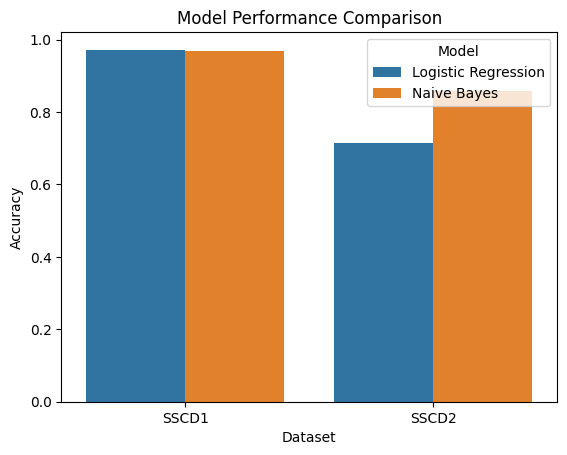

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=results, x="Dataset", y="Accuracy", hue="Model")
plt.title("Model Performance Comparison")
plt.show()

## Discussion

The models performed significantly better on SSCD1 due to its large size (over 5000 samples), which provides sufficient data for learning patterns.

On SSCD2, the dataset is very small (35 samples), which makes the results less stable. Naive Bayes performed better on SSCD2 because it works well with small datasets and sparse text features.

Logistic Regression requires more data to generalize well, which explains its lower performance on SSCD2.

## Conclusion

Logistic Regression achieved the best overall performance on SSCD1, while Naive Bayes performed better on the smaller dataset SSCD2.

This demonstrates that model performance depends on dataset size and characteristics, and that simpler probabilistic models can outperform more complex ones in small-data scenarios.